# “Customer Churn Prediction Using K-Nearest Neighbours (KNN)”

* Question 1 Can customer behavior and account information predict whether a customer is likely to churn?

* Question 2 Which customer characteristics are most strongly associated with churn?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [2]:
telco=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
telco['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
telco['MonthlyCharges'] = pd.to_numeric(telco['MonthlyCharges'],errors='coerce')

In [7]:
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'],errors='coerce')

In [8]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
telco.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
telco.dropna(inplace=True)

In [11]:
telco.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# EDA

## Churn distribution

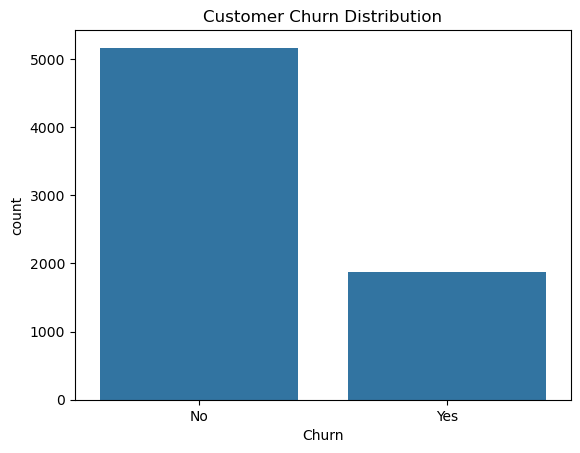

In [12]:
sns.countplot(x='Churn', data=telco)
plt.title('Customer Churn Distribution')
plt.show()

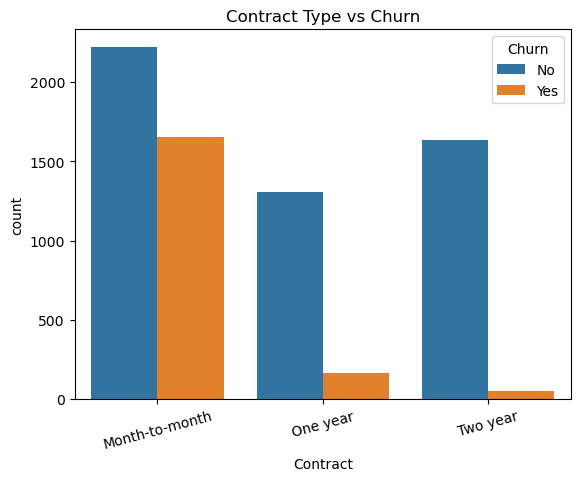

In [13]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=telco
)

plt.xticks(rotation=15)

plt.title('Contract Type vs Churn')

plt.show()

* Customers on month-to-month contracts are more likely to churn.

## Tenure Distribution 

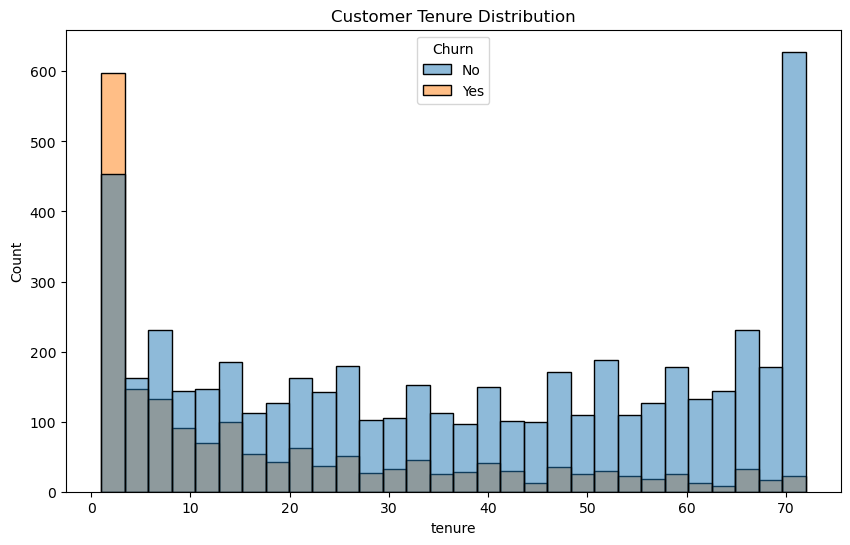

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=telco,
    x='tenure',
    hue='Churn',
    bins=30
)

plt.title('Customer Tenure Distribution')

plt.show()

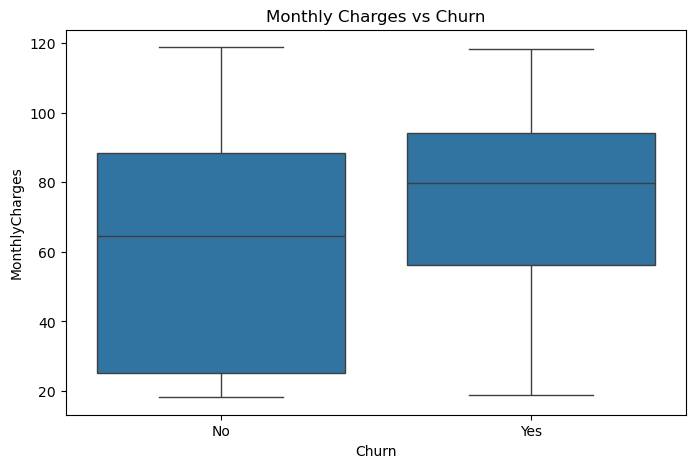

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=telco
)

plt.title('Monthly Charges vs Churn')

plt.show()

## Data Preprocessing

In [17]:
telco = pd.get_dummies(telco,drop_first=True)

In [19]:
X = telco.drop('Churn_Yes', axis=1)
y = telco['Churn_Yes']

In [20]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.30,random_state=42)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
predictions = knn.predict(X_test)

## Confusion matrix , Classification report , Accuracy Score

In [24]:
print(confusion_matrix(y_test, predictions))

[[1409  140]
 [ 368  193]]


In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.79      0.91      0.85      1549
        True       0.58      0.34      0.43       561

    accuracy                           0.76      2110
   macro avg       0.69      0.63      0.64      2110
weighted avg       0.74      0.76      0.74      2110



In [26]:
accuracy = accuracy_score(y_test, predictions)

print('Accuracy:', accuracy)

Accuracy: 0.7592417061611374


## K value 

In [27]:
error_rate = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)

    pred_i = knn.predict(X_test)

    error_rate.append(
        np.mean(pred_i != y_test)
    )

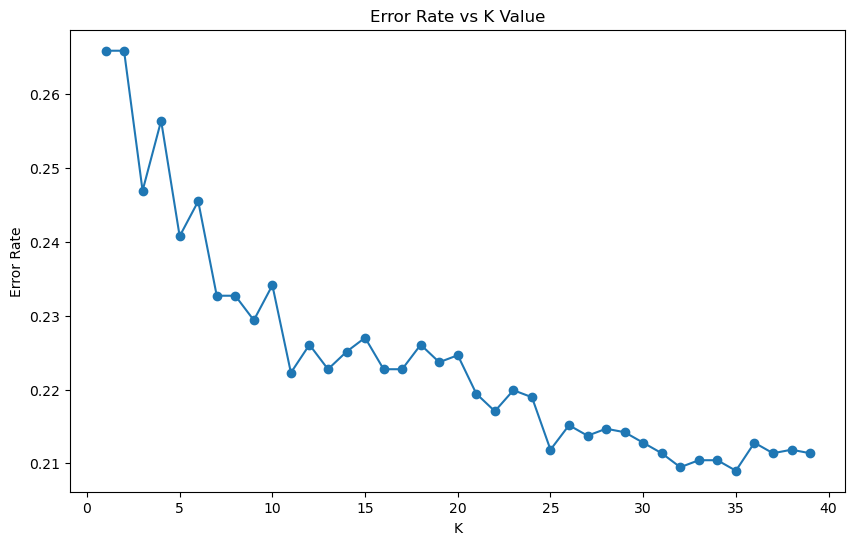

In [28]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,40),
    error_rate,
    marker='o'
)

plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

plt.show()

In [29]:
knn = KNeighborsClassifier(n_neighbors=35)

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

In [30]:
print(confusion_matrix(y_test, predictions))

[[1350  199]
 [ 242  319]]


In [31]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.85      0.87      0.86      1549
        True       0.62      0.57      0.59       561

    accuracy                           0.79      2110
   macro avg       0.73      0.72      0.73      2110
weighted avg       0.79      0.79      0.79      2110



In [32]:
accuracy = accuracy_score(y_test, predictions)

print('Accuracy:', accuracy)

Accuracy: 0.7909952606635071


## Key Findings
* Customers with month-to-month contracts showed significantly higher churn rates.
* Customers with shorter tenure were more likely to leave the company.
* Higher monthly charges were associated with increased churn probability.
* Customers without additional support services demonstrated lower retention.